In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, classification_report)
from sklearn.linear_model import LogisticRegression
import joblib

In [ ]:
#1.  Загрузить CSV и вывести первые 10 строк.
df = pd.read_csv("diabetes.csv")
print(df.head(10))

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   
5            5      116             74              0        0  25.6   
6            3       78             50             32       88  31.0   
7           10      115              0              0        0  35.3   
8            2      197             70             45      543  30.5   
9            8      125             96              0        0   0.0   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   2

In [ ]:
#2.  Вывести .info(), .shape(), .describe().
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
#3.  Проверить на наличие дубликатов и нечисловых значений.
df.duplicated().sum()

np.int64(0)

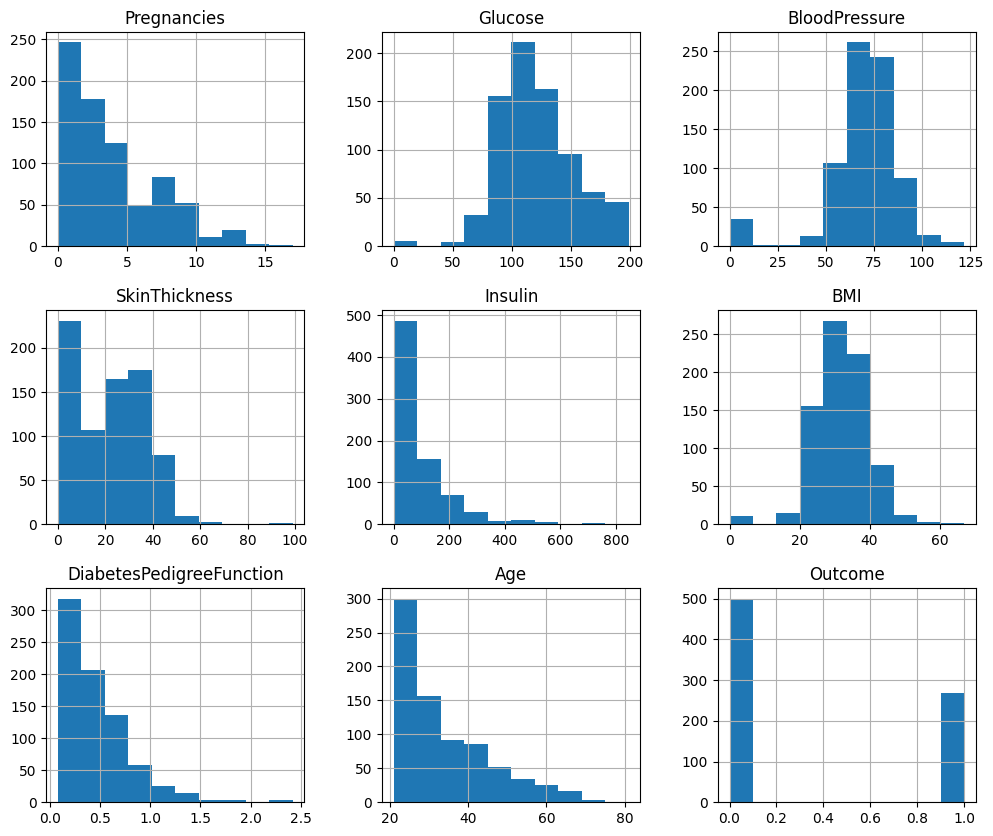

In [ ]:
#4.  Построить распределения (histogram) по числовым признакам.
df.hist(figsize=(12,10))
plt.show()

In [ ]:
#5.  Среднее/медиана по Glucose, BMI, Age, Insulin.
df[['Glucose', 'BMI', 'Age', 'Insulin']].mean().median()

56.52018229166667

In [ ]:
#6.  Кол-во пациентов с Glucose < 70.
(df['Glucose'] < 70).sum()

np.int64(16)

In [ ]:
##%%
#7.  Кол-во пациентов с BMI > 40 (ожирение 3-й степени).
(df['BMI'] > 40).sum()

np.int64(96)

In [ ]:
df[df['Glucose'] <70]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
62,5,44,62,0,0,25.0,0.587,36,0
75,1,0,48,20,0,24.7,0.140,22,0
76,7,62,78,0,0,32.6,0.391,41,0
146,9,57,80,37,0,32.8,0.096,41,0
182,1,0,74,20,23,27.7,0.299,21,0
342,1,0,68,35,0,32.0,0.389,22,0
349,5,0,80,32,0,41.0,0.346,37,1
352,3,61,82,28,0,34.4,0.243,46,0
502,6,0,68,41,0,39.0,0.727,41,1
520,2,68,70,32,66,25.0,0.187,25,0


In [ ]:
#8.  Распределение по Pregnancies — value_counts().
df['Pregnancies'].value_counts()

,count
Pregnancies,
1,135
0,111
2,103
3,75
4,68
5,57
6,50
7,45
8,38


In [ ]:
#9.  Распределение целевой переменной Outcome.
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


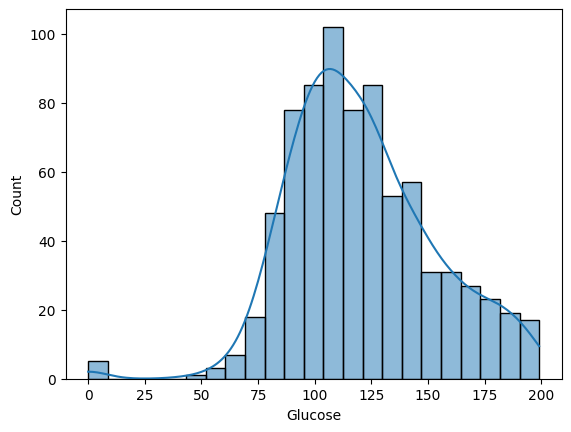

In [ ]:
#10.  distplot / hist по Glucose, BMI, Age.
sns.histplot(df['Glucose'], kde=True)
plt.show()

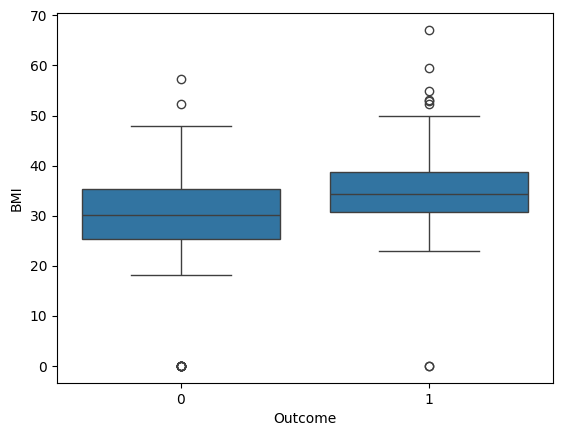

In [ ]:
#11.  Boxplot: Outcome vs BMI, Glucose.
sns.boxplot(x='Outcome', y='BMI', data=df)
plt.show()

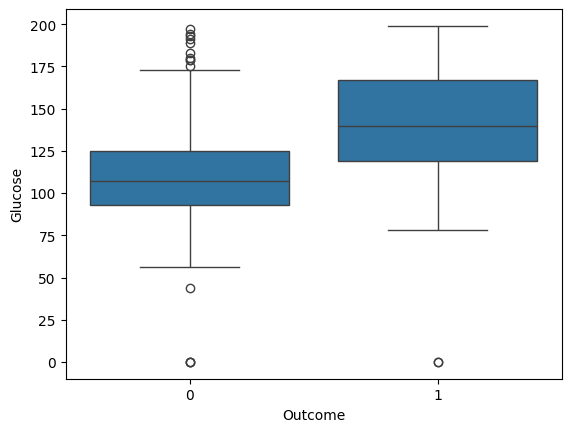

In [ ]:
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.show()

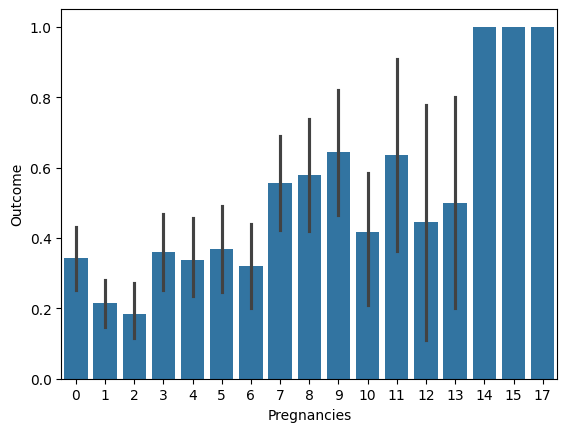

In [ ]:
#12.  Barplot: Pregnancies vs Outcome.
sns.barplot(x='Pregnancies', y='Outcome', data=df)
plt.show()

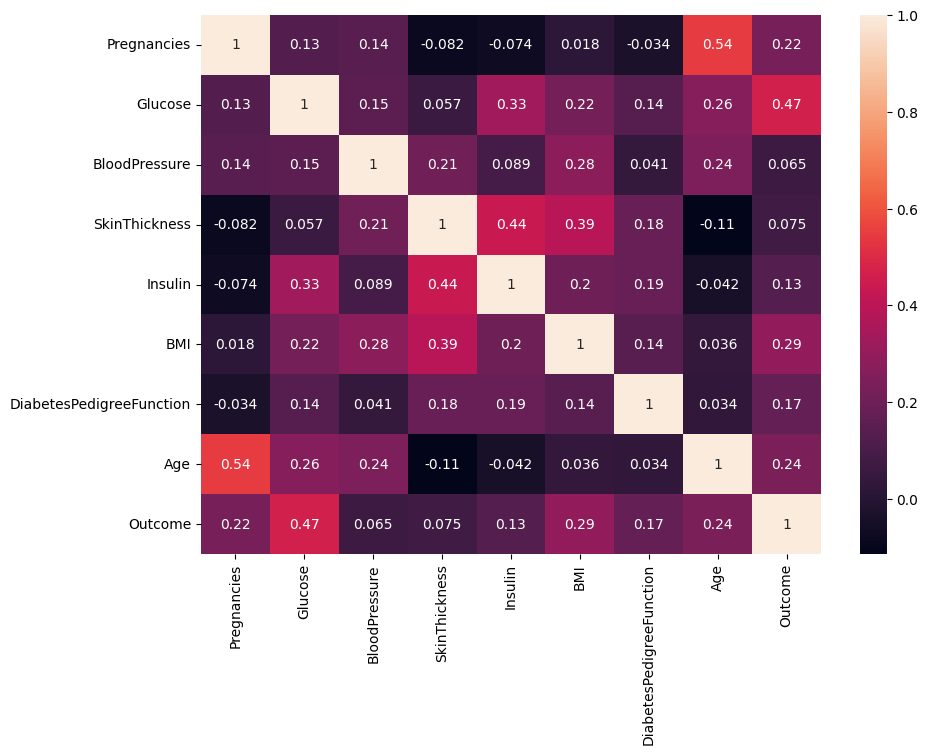

In [ ]:
#13.  Корреляционная матрица + heatmap.
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True)
plt.show()

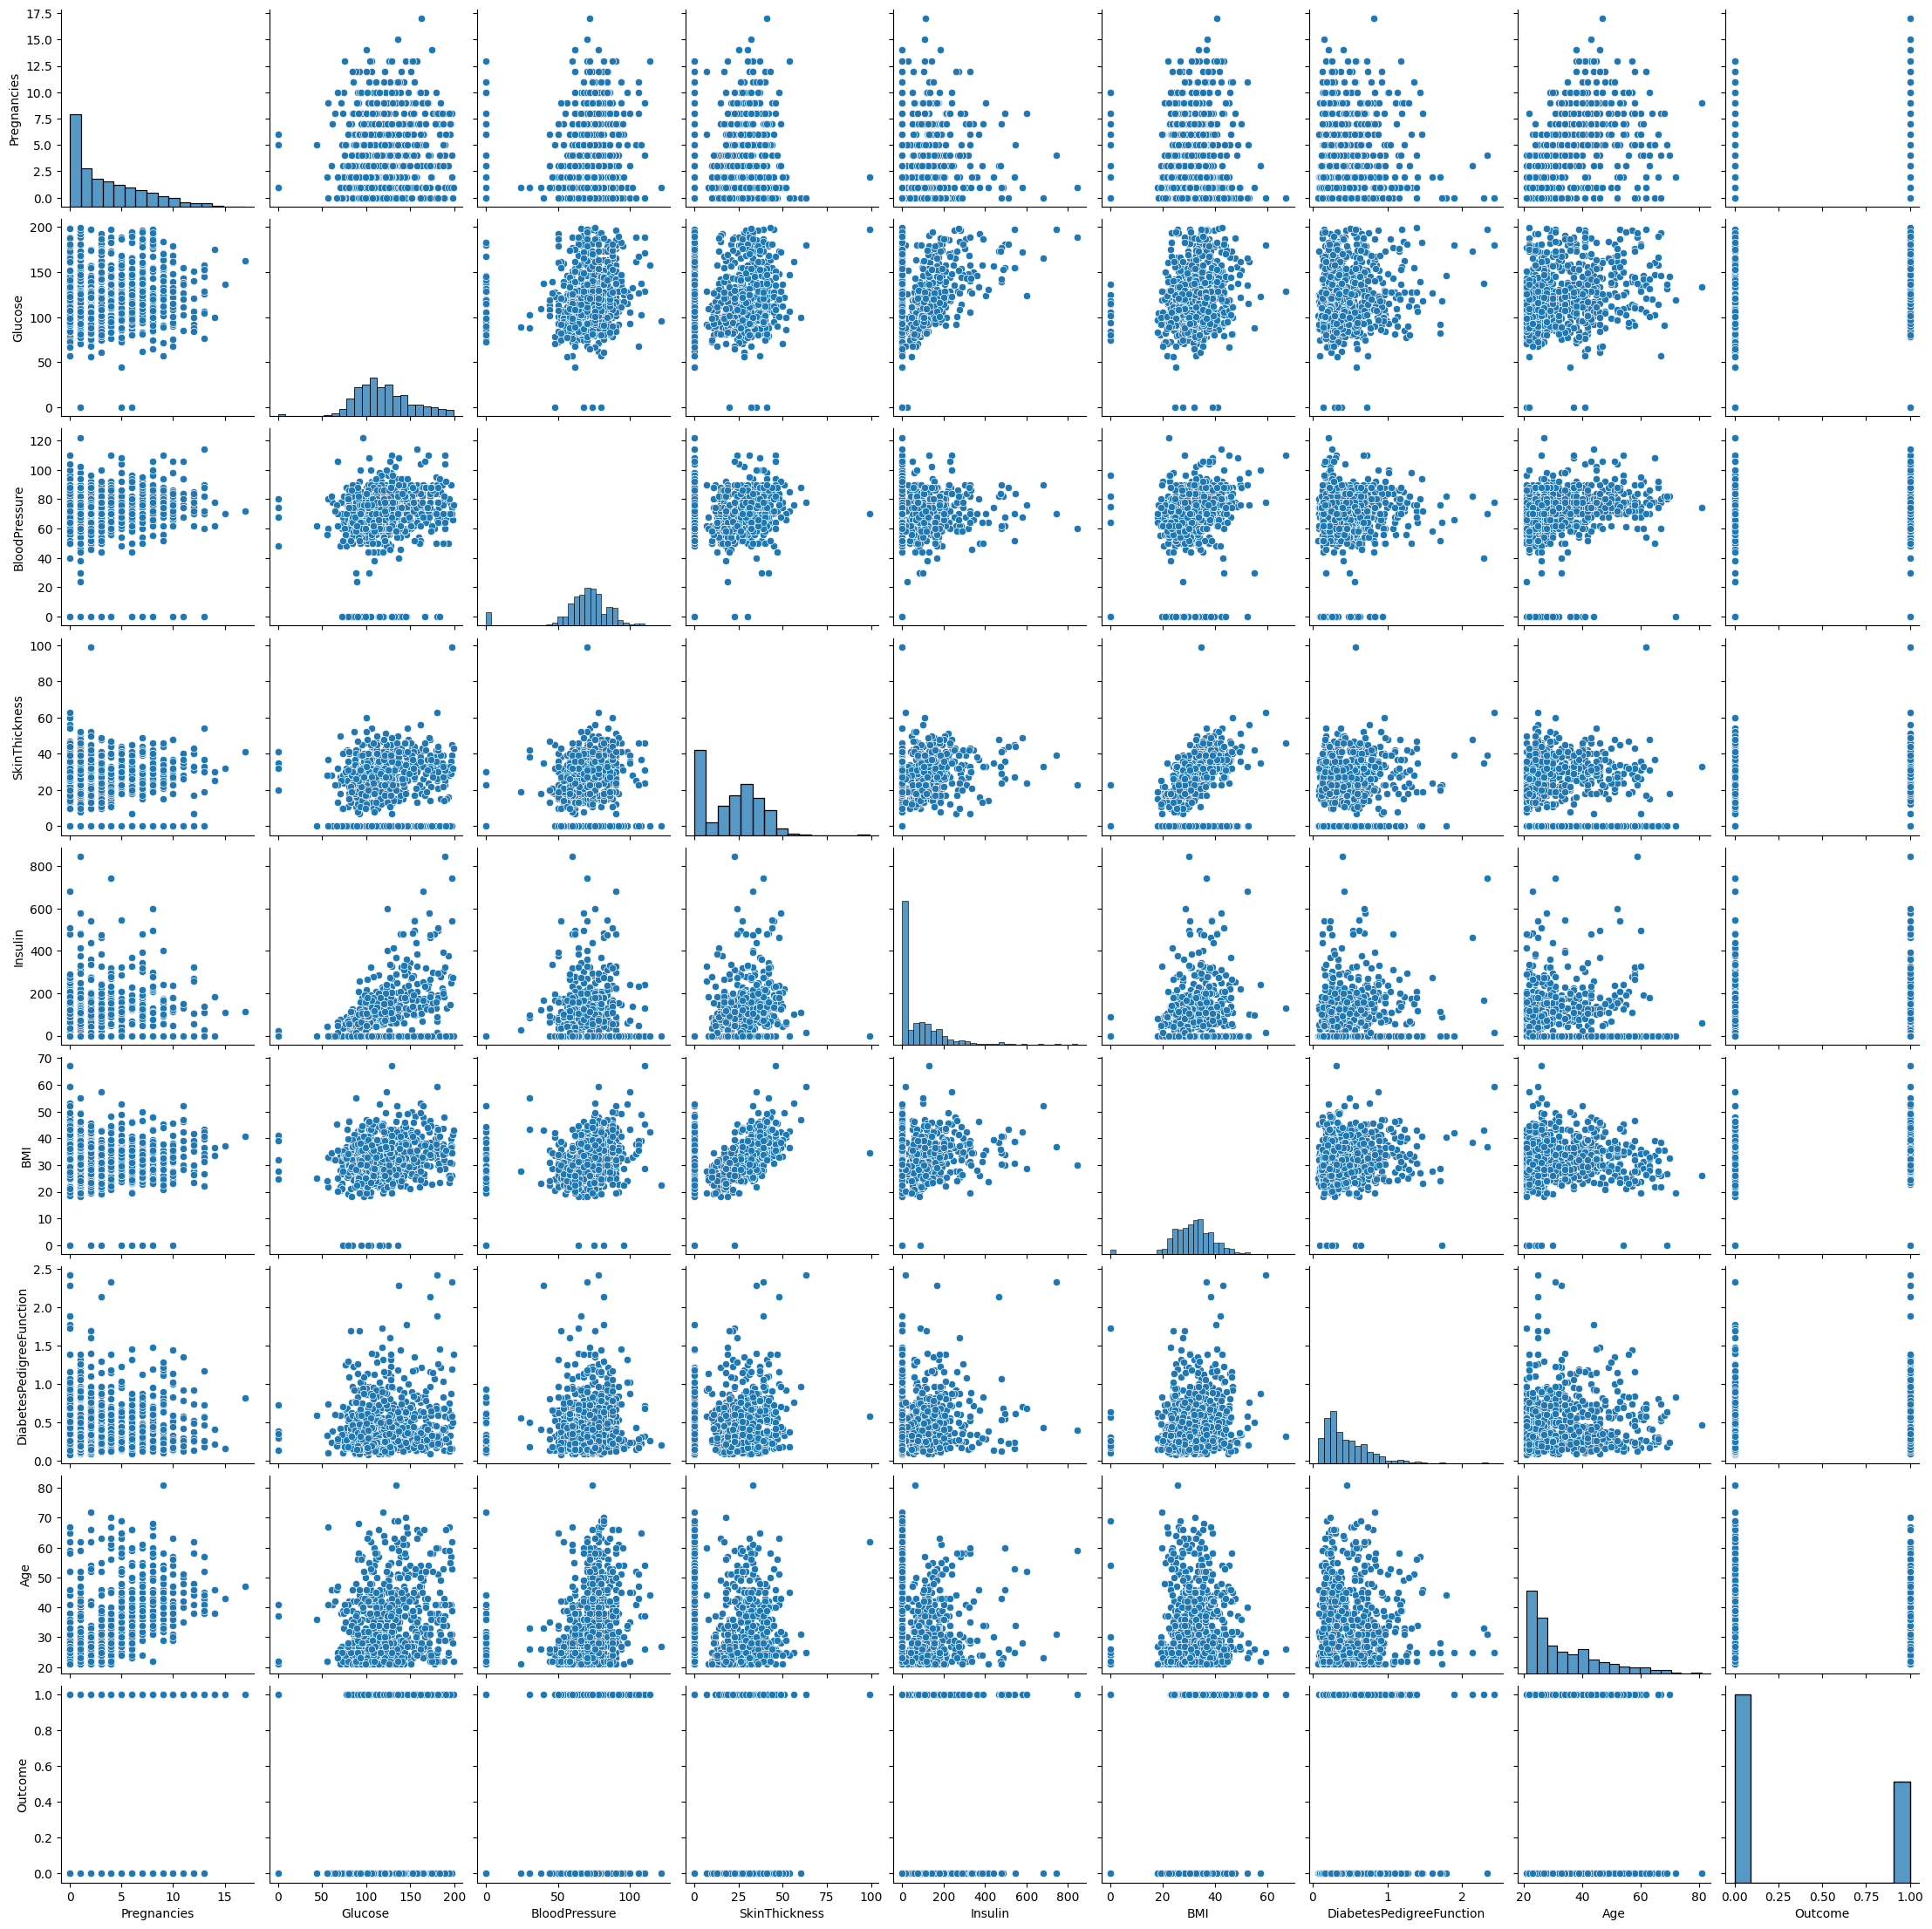

In [ ]:
#14.  Pairplot по числовым признакам.
sns.pairplot(data=df)
plt.show()

In [ ]:
#15.  Проверка пропущенных значений (ноль ≠ null).
df.isnull().sum(),(df == 0).sum()

(Pregnancies                 0
 Glucose                     0
 BloodPressure               0
 SkinThickness               0
 Insulin                     0
 BMI                         0
 DiabetesPedigreeFunction    0
 Age                         0
 Outcome                     0
 dtype: int64,
 Pregnancies                 111
 Glucose                       5
 BloodPressure                35
 SkinThickness               227
 Insulin                     374
 BMI                          11
 DiabetesPedigreeFunction      0
 Age                           0
 Outcome                     500
 dtype: int64)

In [ ]:
#16.  Обработка нулевых значений (например, SkinThickness, Insulin):
#•  либо заполнение средними/медианами,
#•  либо удаление строк.
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in zero_cols:
    df[col] = df[col].replace(0, df[col].median())

In [ ]:
#17.  Масштабирование числовых признаков через StandardScaler.
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df.drop(columns='Outcome'))
scaled_data

array([[ 0.63994726,  0.86604475, -0.03198993, ...,  0.16724016,
         0.46849198,  1.4259954 ],
       [-0.84488505, -1.20506583, -0.5283186 , ..., -0.85155088,
        -0.36506078, -0.19067191],
       [ 1.23388019,  2.01666174, -0.69376149, ..., -1.33183808,
         0.60439732, -0.10558415],
       ...,
       [ 0.3429808 , -0.02157407, -0.03198993, ..., -0.90976751,
        -0.68519336, -0.27575966],
       [-0.84488505,  0.14279979, -1.02464727, ..., -0.34215536,
        -0.37110101,  1.17073215],
       [-0.84488505, -0.94206766, -0.19743282, ..., -0.29849289,
        -0.47378505, -0.87137393]])

In [ ]:
#18.  Определение X (все признаки) и y = Outcome.
X = df.drop('Outcome', axis=1)
y = df['Outcome']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#19.  Разделение train/test: train_test_split(X, y, test_size=0.2).
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#20.  Обучение LogisticRegression из sklearn.linear_model.
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
#21.  Предсказание на тестовых данных.
y_pred = log_model.predict(X_test)
y_proba = log_model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7597402597402597


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.83      0.82        99
           1       0.67      0.64      0.65        55

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.74       154
weighted avg       0.76      0.76      0.76       154



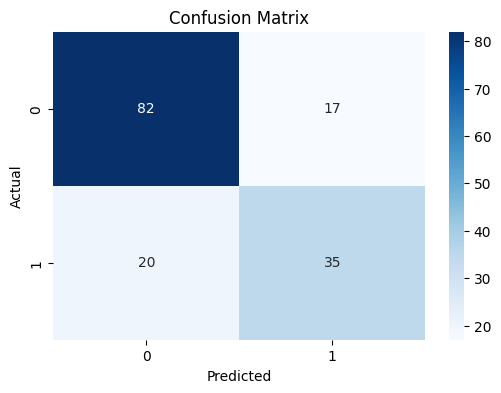

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

ROC AUC: 0.8179981634527089


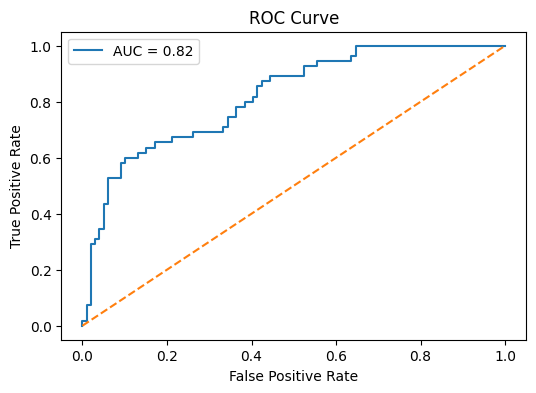

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

roc_auc = roc_auc_score(y_test, y_proba)
print("ROC AUC:", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [ ]:
#23.  Вывод коэффициентов модели coef_, intercept_.
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_model.coef_[0]
})

print(coef_df.sort_values(by="Coefficient", ascending=False))


                    Feature  Coefficient
6  DiabetesPedigreeFunction     0.590131
5                       BMI     0.106051
0               Pregnancies     0.066199
1                   Glucose     0.038540
7                       Age     0.033342
3             SkinThickness     0.005408
4                   Insulin    -0.002191
2             BloodPressure    -0.014477


In [ ]:
print("Коэффициенты модели:")
print(log_model.coef_)

print("Свободный член:")
print(log_model.intercept_)

Коэффициенты модели:
[[ 0.06619935  0.03854046 -0.01447707  0.00540782 -0.0021911   0.10605128
   0.59013063  0.03334206]]
Свободный член:
[-9.51686234]


In [ ]:
import pickle

with open("logistic_model.pkl", "wb") as f:
    pickle.dump(log_model, f)

In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,30.5,33.6,0.627,50,1
1,1,85,66,29,30.5,26.6,0.351,31,0
2,8,183,64,23,30.5,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180.0,32.9,0.171,63,0
764,2,122,70,27,30.5,36.8,0.340,27,0
765,5,121,72,23,112.0,26.2,0.245,30,0
766,1,126,60,23,30.5,30.1,0.349,47,1


In [ ]:

#25.Посчитать метрики:

accuracy_score(y_pred, y_test)

0.7597402597402597

In [ ]:
#Accuracy
round(accuracy_score(y_pred, y_test) * 100, 2)

75.97

In [ ]:
#Recal
round(recall_score(y_pred, y_test), 2)

0.67

In [ ]:
#F1-score
round(f1_score(y_pred, y_test), 2)

0.65

In [ ]:

#F1-score
round(f1_score(y_pred, y_test), 2)


0.65

In [ ]:

#27.Сохранить модель (joblib или pickle).
import joblib

joblib.dump(log_model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')